In [20]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.runner  import setup_trainer
from ncpu.config import TINY_AND_GATE_TRAINING_CONFIG
import mediapy as media

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from datetime import datetime
from ncpu.utils import print_tensor, sequence_batch_to_html_gifs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
config = TINY_AND_GATE_TRAINING_CONFIG
trainer = setup_trainer(config)

Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([16, 32, 32]) -> torch.Size([16, 32, 32])
  first_state: torch.Size([16, 16, 32, 32])
  rollout: torch.Size([16, 11, 16, 32, 32])
  loss: 0.00509584229439497
Sanity check completed successfully


In [22]:
# state_dict = torch.load("notebooks/checkpoints/ncpu_127580_20251130_203719.pth")
# trainer.nca.load_state_dict(state_dict)

loss=0.005084:   0%|          | 0/500000 [00:00<?, ?it/s]

AttributeError: 'NCPUTrainer' object has no attribute 'history'

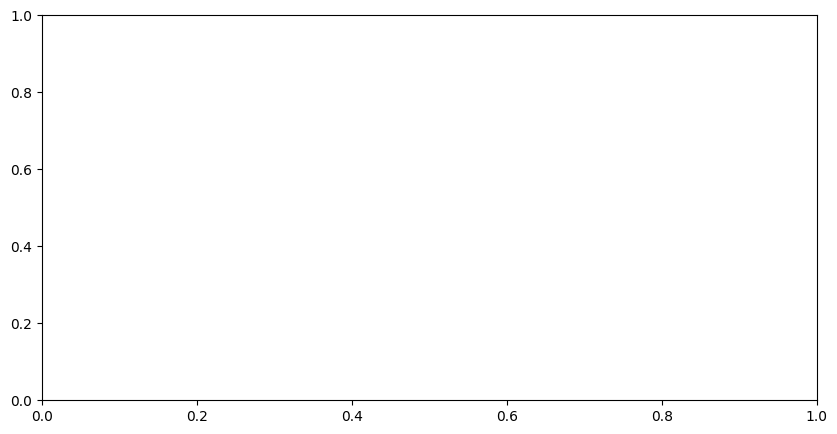

In [23]:
pbar = tqdm(range(500_000))

for i in pbar:
    info = trainer.optim_step(steps=(30, 80), save_history=i % 5000 == 0)
    loss = info["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 250 == 0:
        clear_output(wait=False)
        display(pbar.container)
        fig, ax = plt.subplots(figsize=(10, 5))
        loss = [h["loss"].item() for h in trainer.history]
        ax.scatter(range(len(loss)), loss, s=1)
        ax.set_yscale("log")
        plt.close(fig)
        display(fig)

        print_tensor("inp    ", info["inp"])
        print_tensor("out    ", info["out"])
        print_tensor("nca_out", info["nca_out"])

        to_show = 8
        inp = info["inp"][:to_show]
        out = info["out"][:to_show]
        nca_out = info["nca_out"][:to_show]
        rollout = info["rollout"][:to_show]
        io = torch.cat([inp, out, nca_out], dim=0)

        media.show_images(io.detach().cpu(), columns=to_show, width=100, height=100)
        sequence_batch_to_html_gifs(rollout, columns=to_show, fps=10)

        it = len(trainer.history)
        path = f"./checkpoints/ncpu_{it}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
        torch.save(trainer.nca.state_dict(), path)